# Random Forest - Hyperparameter Search Strategies
## Wine Quality Dataset (Binary Classification: quality >= 5 vs < 5)
### Comparing: Grid Search | Random Search | Successive Halving

## 1. Load Dataset & Preprocessing

In [29]:
import pandas as pd
import numpy as np

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# df = pd.read_csv("winequality-red.csv")

print('Dataset Shape:', df.shape)
print('\nQuality Distribution:')
print(df['quality'].value_counts().sort_index())
df.head()

Dataset Shape: (1599, 12)

Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


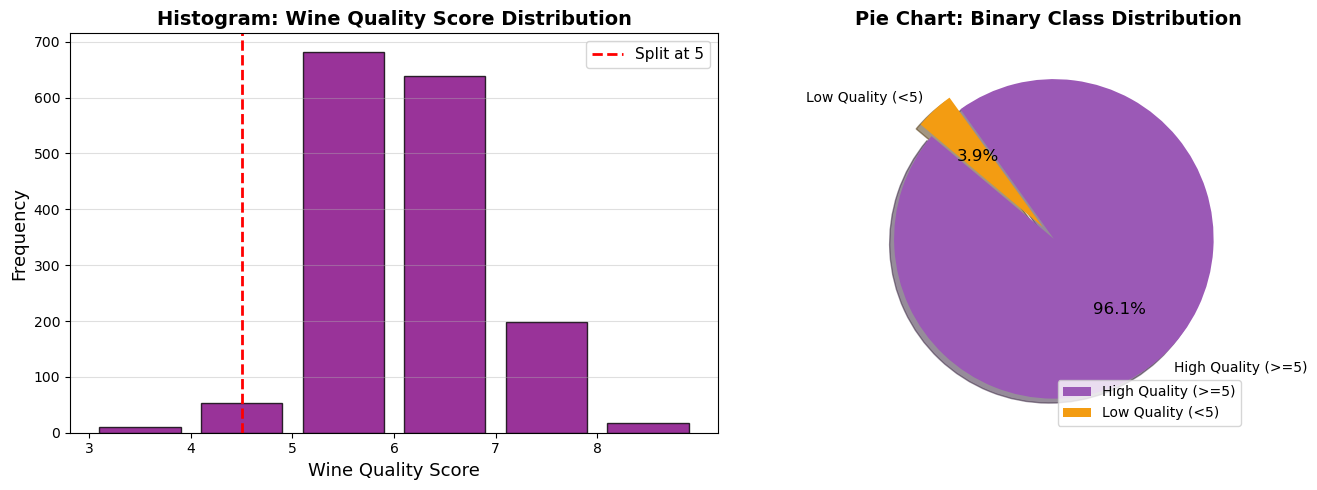

High Quality (>=5): 1536 | Low Quality (<5): 63


In [30]:
import matplotlib.pyplot as plt

# Binary transformation
df['binary_quality'] = (df['quality'] >= 5).astype(int)
class_counts = df['binary_quality'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of original quality
axes[0].hist(df['quality'], bins=range(3, 10), color='purple', edgecolor='black', alpha=0.8, rwidth=0.8)
axes[0].set_xlabel('Wine Quality Score', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].set_title('Histogram: Wine Quality Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(3, 9))
axes[0].grid(axis='y', alpha=0.4)
# Add vertical line showing split
axes[0].axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='Split at 5')
axes[0].legend(fontsize=11)

# Pie chart of binary classes
labels = ['High Quality (>=5)', 'Low Quality (<5)']
colors = ['#9b59b6', '#f39c12']
wedges, texts, autotexts = axes[1].pie(
    [class_counts[1], class_counts[0]],
    labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=140, explode=(0.05, 0.05), shadow=True
)
for at in autotexts:
    at.set_fontsize(12)
axes[1].set_title('Pie Chart: Binary Class Distribution', fontsize=14, fontweight='bold')
axes[1].legend(labels, loc='lower right')

plt.tight_layout()
plt.savefig('rf_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'High Quality (>=5): {class_counts[1]} | Low Quality (<5): {class_counts[0]}')

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['quality', 'binary_quality'], axis=1)
y = df['binary_quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Training set: {X_train_sc.shape}')
print(f'Test set:     {X_test_sc.shape}')

Training set: (1279, 11)
Test set:     (320, 11)


## 2. Hyperparameter Search - Random Forest

Random Forest has a **larger hyperparameter space** than Decision Tree.
This makes the comparison even more meaningful!

| Method | Strategy |
|--------|----------|
| **Grid Search** | All combinations — thorough but expensive |
| **Random Search** | Stochastic sampling — fast, near-optimal |
| **Successive Halving** | Tournament-style elimination — smart & scalable |

In [32]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint

# Parameter grid (kept focused to allow Grid Search to complete)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

results = {}
total_combinations = 3*3*3*3*2
print(f'Total Grid combinations: {total_combinations}')
print('Initiating searches...')

Total Grid combinations: 162
Initiating searches...


### 2.1 Grid Search CV

In [33]:
rf = RandomForestClassifier(random_state=42)

start = time.time()
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)
grid_time = time.time() - start

grid_test_acc = accuracy_score(y_test, grid_search.predict(X_test_sc))

results['Grid Search'] = {
    'best_params': grid_search.best_params_,
    'cv_score': grid_search.best_score_,
    'test_accuracy': grid_test_acc,
    'time': grid_time,
    'n_candidates': len(grid_search.cv_results_['params'])
}

print('=== GRID SEARCH RESULTS ===')
print(f'Time taken:       {grid_time:.2f} seconds')
print(f'Candidates tried: {results["Grid Search"]["n_candidates"]}')
print(f'Best CV Score:    {grid_search.best_score_:.4f}')
print(f'Test Accuracy:    {grid_test_acc:.4f}')
print(f'Best Params:      {grid_search.best_params_}')

=== GRID SEARCH RESULTS ===
Time taken:       64.55 seconds
Candidates tried: 162
Best CV Score:    0.9625
Test Accuracy:    0.9594
Best Params:      {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


### 2.2 Random Search CV

In [34]:
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2']
}

start = time.time()
random_search = RandomizedSearchCV(
    rf, param_dist, n_iter=30, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=42, verbose=0
)
random_search.fit(X_train_sc, y_train)
random_time = time.time() - start

random_test_acc = accuracy_score(y_test, random_search.predict(X_test_sc))

results['Random Search'] = {
    'best_params': random_search.best_params_,
    'cv_score': random_search.best_score_,
    'test_accuracy': random_test_acc,
    'time': random_time,
    'n_candidates': 30
}

print('=== RANDOM SEARCH RESULTS ===')
print(f'Time taken:       {random_time:.2f} seconds')
print(f'Candidates tried: 30')
print(f'Best CV Score:    {random_search.best_score_:.4f}')
print(f'Test Accuracy:    {random_test_acc:.4f}')
print(f'Best Params:      {random_search.best_params_}')

=== RANDOM SEARCH RESULTS ===
Time taken:       17.03 seconds
Candidates tried: 30
Best CV Score:    0.9617
Test Accuracy:    0.9594
Best Params:      {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 216}


### 2.3 Successive Halving

In [35]:
start = time.time()
halving_search = HalvingGridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy',
    factor=3, min_resources='exhaust', n_jobs=-1, random_state=42, verbose=0
)
halving_search.fit(X_train_sc, y_train)
halving_time = time.time() - start

halving_test_acc = accuracy_score(y_test, halving_search.predict(X_test_sc))

results['Successive Halving'] = {
    'best_params': halving_search.best_params_,
    'cv_score': halving_search.best_score_,
    'test_accuracy': halving_test_acc,
    'time': halving_time,
    'n_candidates': len(set(str(p) for p in halving_search.cv_results_['params']))
}

print('=== SUCCESSIVE HALVING RESULTS ===')
print(f'Time taken:       {halving_time:.2f} seconds')
print(f'Best CV Score:    {halving_search.best_score_:.4f}')
print(f'Test Accuracy:    {halving_test_acc:.4f}')
print(f'Best Params:      {halving_search.best_params_}')

=== SUCCESSIVE HALVING RESULTS ===
Time taken:       41.89 seconds
Best CV Score:    0.9592
Test Accuracy:    0.9594
Best Params:      {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


## 3. Comparison Summary Table

In [36]:
import pandas as pd

summary_df = pd.DataFrame({
    'Method': list(results.keys()),
    'Time (s)': [results[m]['time'] for m in results],
    'Candidates': [results[m]['n_candidates'] for m in results],
    'Best CV Score': [results[m]['cv_score'] for m in results],
    'Test Accuracy': [results[m]['test_accuracy'] for m in results],
    'Efficiency (Acc/s)': [results[m]['test_accuracy']/results[m]['time'] for m in results]
})
summary_df = summary_df.set_index('Method').round(4)
print('\n=== RANDOM FOREST: COMPREHENSIVE COMPARISON ===')
print(summary_df.to_string())


=== RANDOM FOREST: COMPREHENSIVE COMPARISON ===
                    Time (s)  Candidates  Best CV Score  Test Accuracy  Efficiency (Acc/s)
Method                                                                                    
Grid Search          64.5532         162         0.9625         0.9594              0.0149
Random Search        17.0252          30         0.9617         0.9594              0.0564
Successive Halving   41.8875         162         0.9592         0.9594              0.0229


## 4. Visualization - Comparison Charts

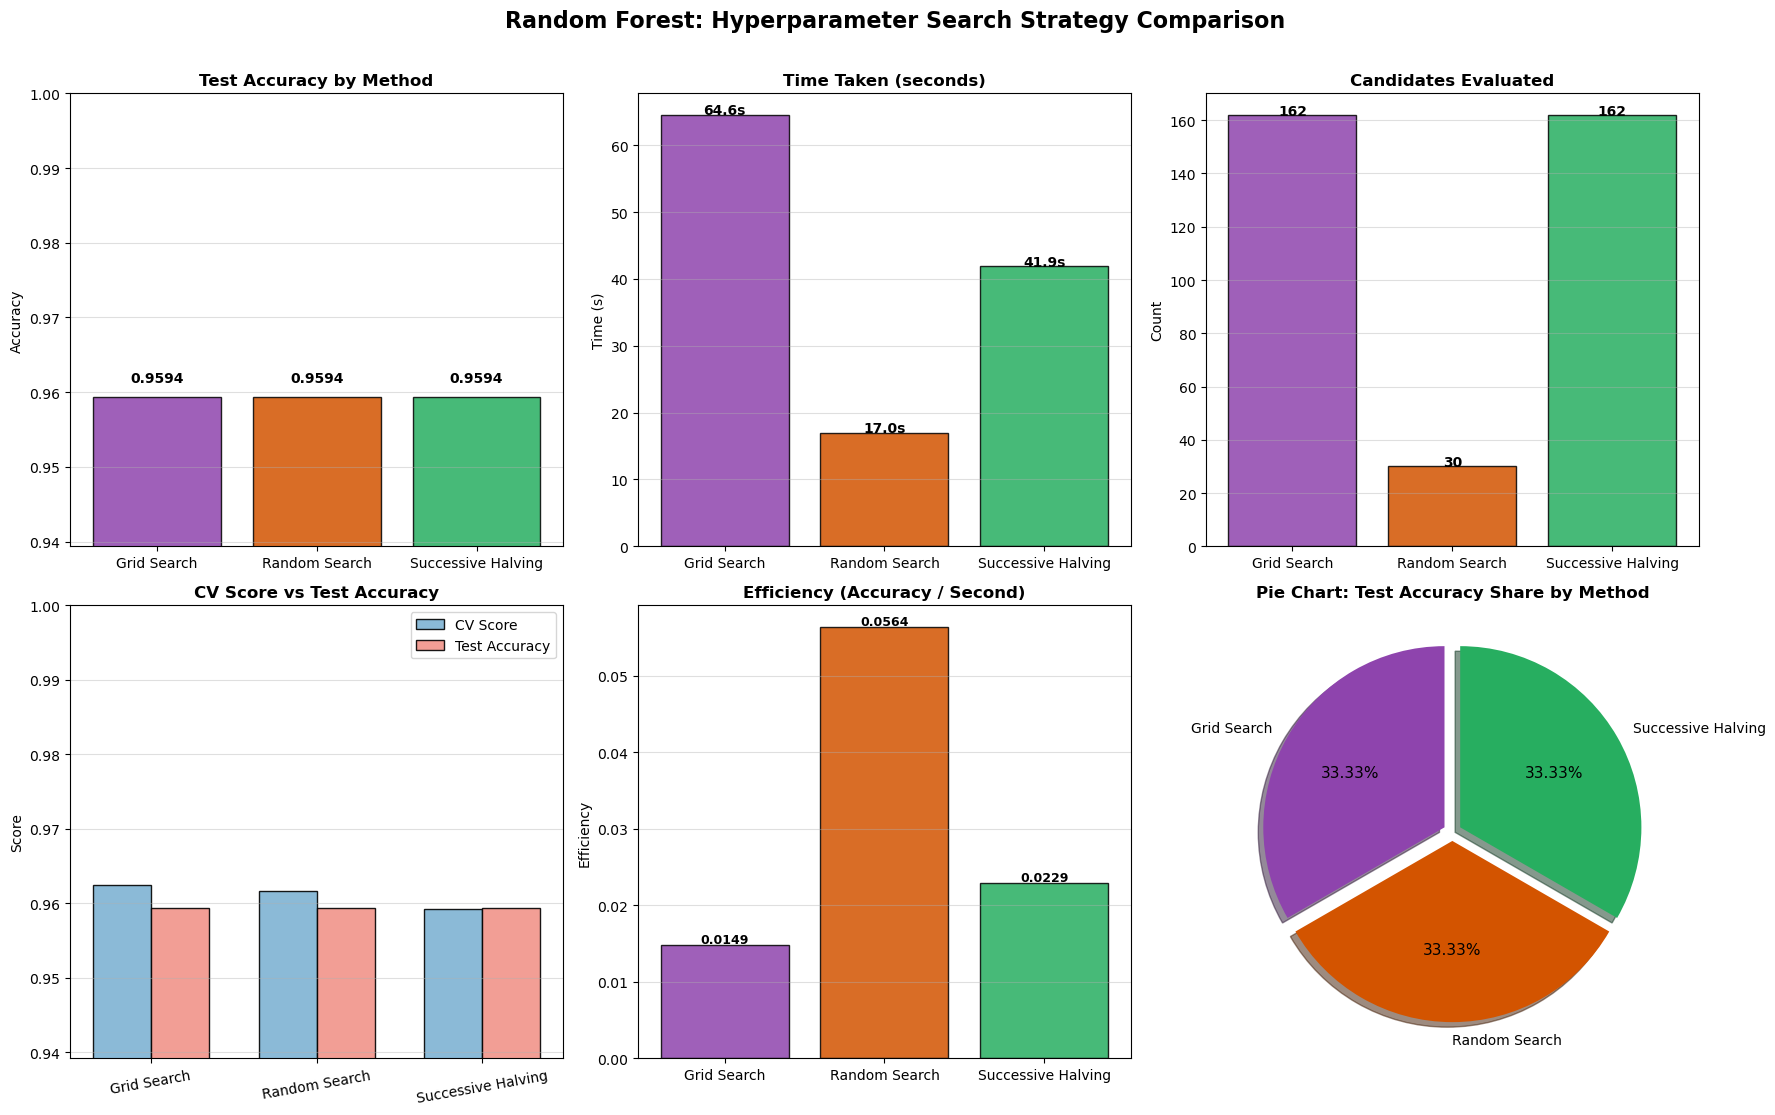

In [37]:
methods = list(results.keys())
test_accs = [results[m]['test_accuracy'] for m in methods]
cv_scores = [results[m]['cv_score'] for m in methods]
times = [results[m]['time'] for m in methods]
candidates = [results[m]['n_candidates'] for m in methods]
efficiency = [results[m]['test_accuracy']/results[m]['time'] for m in methods]

colors = ['#8e44ad', '#d35400', '#27ae60']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Random Forest: Hyperparameter Search Strategy Comparison', fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Test Accuracy Histogram ---
bars = axes[0,0].bar(methods, test_accs, color=colors, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Test Accuracy by Method', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(min(test_accs)-0.02, 1.0)
axes[0,0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, test_accs):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Time Taken Histogram ---
bars2 = axes[0,1].bar(methods, times, color=colors, edgecolor='black', alpha=0.85)
axes[0,1].set_title('Time Taken (seconds)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Time (s)')
axes[0,1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars2, times):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{val:.1f}s', ha='center', fontsize=10, fontweight='bold')

# --- Plot 3: Candidates Evaluated ---
bars3 = axes[0,2].bar(methods, candidates, color=colors, edgecolor='black', alpha=0.85)
axes[0,2].set_title('Candidates Evaluated', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Count')
axes[0,2].grid(axis='y', alpha=0.4)
for bar, val in zip(bars3, candidates):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val), ha='center', fontsize=10, fontweight='bold')

# --- Plot 4: CV vs Test Accuracy Grouped Bar ---
x = np.arange(len(methods))
width = 0.35
axes[1,0].bar(x - width/2, cv_scores, width, label='CV Score', color='#7fb3d3', edgecolor='black', alpha=0.9)
axes[1,0].bar(x + width/2, test_accs, width, label='Test Accuracy', color='#f1948a', edgecolor='black', alpha=0.9)
axes[1,0].set_title('CV Score vs Test Accuracy', fontsize=12, fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(methods, rotation=10)
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.4)
axes[1,0].set_ylim(min(cv_scores)-0.02, 1.0)

# --- Plot 5: Efficiency Histogram ---
bars5 = axes[1,1].bar(methods, efficiency, color=colors, edgecolor='black', alpha=0.85)
axes[1,1].set_title('Efficiency (Accuracy / Second)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Efficiency')
axes[1,1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars5, efficiency):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# --- Plot 6: Pie Chart - Accuracy Distribution ---
wedges, texts, autotexts = axes[1,2].pie(
    test_accs, labels=methods, colors=colors, autopct='%1.2f%%',
    startangle=90, explode=[0.05]*3, shadow=True
)
for at in autotexts:
    at.set_fontsize(11)
axes[1,2].set_title('Pie Chart: Test Accuracy Share by Method', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance & Best Model Report

Best Method: Grid Search  |  Test Accuracy: 0.9594

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Low (<5)       0.00      0.00      0.00        13
  High (>=5)       0.96      1.00      0.98       307

    accuracy                           0.96       320
   macro avg       0.48      0.50      0.49       320
weighted avg       0.92      0.96      0.94       320



c:\Users\kunal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kunal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kunal\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


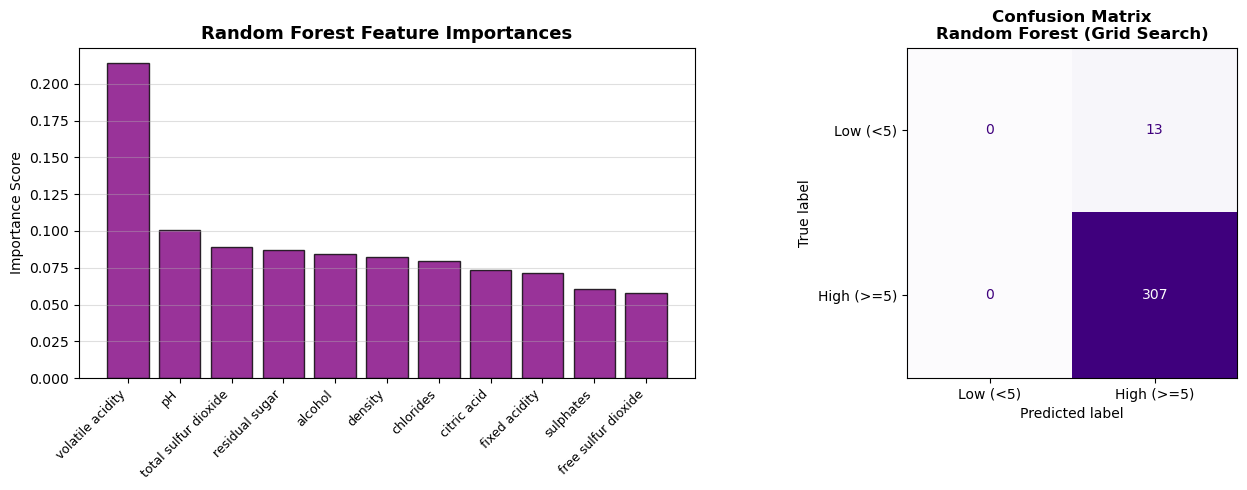

In [38]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_method = max(results, key=lambda m: results[m]['test_accuracy'])
searchers = {'Grid Search': grid_search, 'Random Search': random_search, 'Successive Halving': halving_search}
best_model = searchers[best_method].best_estimator_
y_pred = best_model.predict(X_test_sc)

print(f'Best Method: {best_method}  |  Test Accuracy: {results[best_method]["test_accuracy"]:.4f}')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=['Low (<5)', 'High (>=5)']))

# Feature Importance + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Importances
importances = best_model.feature_importances_
feat_names = X.columns
sorted_idx = np.argsort(importances)[::-1]
axes[0].bar(range(len(feat_names)), importances[sorted_idx], color='purple', edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(feat_names)))
axes[0].set_xticklabels(feat_names[sorted_idx], rotation=45, ha='right', fontsize=9)
axes[0].set_title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].grid(axis='y', alpha=0.4)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Low (<5)', 'High (>=5)'],
                                        colorbar=False, ax=axes[1], cmap='Purples')
axes[1].set_title(f'Confusion Matrix\nRandom Forest ({best_method})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_feature_importance_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analysis & Conclusion

In [39]:
print('=' * 65)
print('       RANDOM FOREST - HYPERPARAMETER SEARCH ANALYSIS')
print('=' * 65)
print(summary_df.to_string())
print()

fastest = min(results, key=lambda m: results[m]['time'])
most_accurate = max(results, key=lambda m: results[m]['test_accuracy'])
most_efficient = max(results, key=lambda m: results[m]['test_accuracy']/results[m]['time'])

print(f' Fastest Method:         {fastest} ({results[fastest]["time"]:.2f}s)')
print(f' Most Accurate Method:   {most_accurate} ({results[most_accurate]["test_accuracy"]:.4f})')
print(f' Most Efficient Method:  {most_efficient}')
print()
print('KEY INSIGHTS:')
print('  Grid Search     - Best when parameter space is small.')
print('                    For Random Forest with many params, it becomes very slow.')
print('  Random Search   - Excellent for large/continuous spaces.')
print('                    Finds good solutions in a fraction of the time.')
print('  Succ. Halving   - Smart resource allocation via tournament elimination.')
print('                    Ideal for compute-heavy models like Random Forest.')
print()
print('RECOMMENDATION: Use Random Search or Successive Halving for Random Forest.')
print('  Random Forest is compute-intensive; Grid Search is rarely justified.')

       RANDOM FOREST - HYPERPARAMETER SEARCH ANALYSIS
                    Time (s)  Candidates  Best CV Score  Test Accuracy  Efficiency (Acc/s)
Method                                                                                    
Grid Search          64.5532         162         0.9625         0.9594              0.0149
Random Search        17.0252          30         0.9617         0.9594              0.0564
Successive Halving   41.8875         162         0.9592         0.9594              0.0229

 Fastest Method:         Random Search (17.03s)
 Most Accurate Method:   Grid Search (0.9594)
 Most Efficient Method:  Random Search

KEY INSIGHTS:
  Grid Search     - Best when parameter space is small.
                    For Random Forest with many params, it becomes very slow.
  Random Search   - Excellent for large/continuous spaces.
                    Finds good solutions in a fraction of the time.
  Succ. Halving   - Smart resource allocation via tournament elimination.
       